In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("data/online_retail.csv")

In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
df.shape

(541909, 8)

In [7]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [8]:
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [11]:
print("Rows and columns:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Rows and columns: (541909, 8)

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate rows: 5268


In [12]:
print("Negative quantity:", (df["Quantity"] < 0).sum())
print("Zero quantity:", (df["Quantity"] == 0).sum())
print("Negative unit price:", (df["UnitPrice"] < 0).sum())
print("Zero unit price:", (df["UnitPrice"] == 0).sum())

Negative quantity: 10624
Zero quantity: 0
Negative unit price: 2
Zero unit price: 2515


In [13]:
df[df["Quantity"] < 0][
    ["InvoiceNo", "StockCode", "Description", "Quantity", "InvoiceDate", "UnitPrice"]
].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25


In [14]:
print("Negative quantity:", (df["Quantity"] < 0).sum())
print("Zero quantity:", (df["Quantity"] == 0).sum())
print("Negative unit price:", (df["UnitPrice"] < 0).sum())
print("Zero unit price:", (df["UnitPrice"] == 0).sum())

Negative quantity: 10624
Zero quantity: 0
Negative unit price: 2
Zero unit price: 2515


In [15]:
print("Cancelled invoices:", df["InvoiceNo"].astype(str).str.startswith("C").sum())

Cancelled invoices: 9288


In [16]:
sales_df = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0) &
    (~df["InvoiceNo"].astype(str).str.startswith("C"))
].copy()

In [17]:
sales_df["Revenue"] = sales_df["Quantity"] * sales_df["UnitPrice"]

In [18]:
print("Original rows:", len(df))
print("Clean sales rows:", len(sales_df))
print("Rows removed:", len(df) - len(sales_df))
print("Total revenue:", sales_df["Revenue"].sum())

Original rows: 541909
Clean sales rows: 530104
Rows removed: 11805
Total revenue: 10666684.544


In [19]:
sales_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [20]:
sales_df.duplicated().sum()

np.int64(5226)

In [21]:
sales_df = sales_df.drop_duplicates().copy()

In [22]:
print("Rows after removing duplicates:", len(sales_df))
print("Remaining duplicates:", sales_df.duplicated().sum())

Rows after removing duplicates: 524878
Remaining duplicates: 0


In [23]:
sales_df.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
Revenue             0
dtype: int64

In [24]:
print("Rows:", sales_df.shape[0])
print("Columns:", sales_df.shape[1])
print("Duplicate rows:", sales_df.duplicated().sum())
print("Total Revenue:", sales_df["Revenue"].sum())
print("Total Quantity:", sales_df["Quantity"].sum())
print("Unique Invoices:", sales_df["InvoiceNo"].nunique())
print("Unique Products:", sales_df["StockCode"].nunique())
print("Unique Countries:", sales_df["Country"].nunique())

Rows: 524878
Columns: 9
Duplicate rows: 0
Total Revenue: 10642110.804000001
Total Quantity: 5572420
Unique Invoices: 19960
Unique Products: 3922
Unique Countries: 38


In [25]:
sales_df.info()

<class 'pandas.DataFrame'>
Index: 524878 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    524878 non-null  str    
 1   StockCode    524878 non-null  str    
 2   Description  524878 non-null  str    
 3   Quantity     524878 non-null  int64  
 4   InvoiceDate  524878 non-null  str    
 5   UnitPrice    524878 non-null  float64
 6   CustomerID   392692 non-null  float64
 7   Country      524878 non-null  str    
 8   Revenue      524878 non-null  float64
dtypes: float64(3), int64(1), str(5)
memory usage: 40.0 MB


In [26]:
total_revenue = sales_df["Revenue"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 10642110.804000001


In [27]:
total_quantity = sales_df["Quantity"].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 5572420


In [28]:
total_orders = sales_df["InvoiceNo"].nunique()

print("Total Orders:", total_orders)

Total Orders: 19960


In [29]:
average_order_value = total_revenue / total_orders

print("Average Order Value:", average_order_value)

Average Order Value: 533.171883967936


In [30]:
print("========== SALES KPIs ==========")
print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value: £{average_order_value:,.2f}")

========== SALES KPIs ==========
Total Revenue: £10,642,110.80
Total Quantity Sold: 5,572,420
Total Orders: 19,960
Average Order Value: £533.17


In [31]:
sales_df["InvoiceDate"] = pd.to_datetime(sales_df["InvoiceDate"])

In [32]:
sales_df["Month"] = sales_df["InvoiceDate"].dt.to_period("M")

In [33]:
monthly_revenue = (
    sales_df.groupby("Month")["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue

,Month,Revenue
0,2010-12,821452.730
1,2011-01,689811.610
2,2011-02,522545.560
3,2011-03,716215.260
4,2011-04,536968.491
5,2011-05,769296.610
6,2011-06,760547.010
7,2011-07,718076.121
8,2011-08,757841.380
9,2011-09,1056435.192


In [34]:
monthly_revenue["Month"] = monthly_revenue["Month"].dt.to_timestamp()

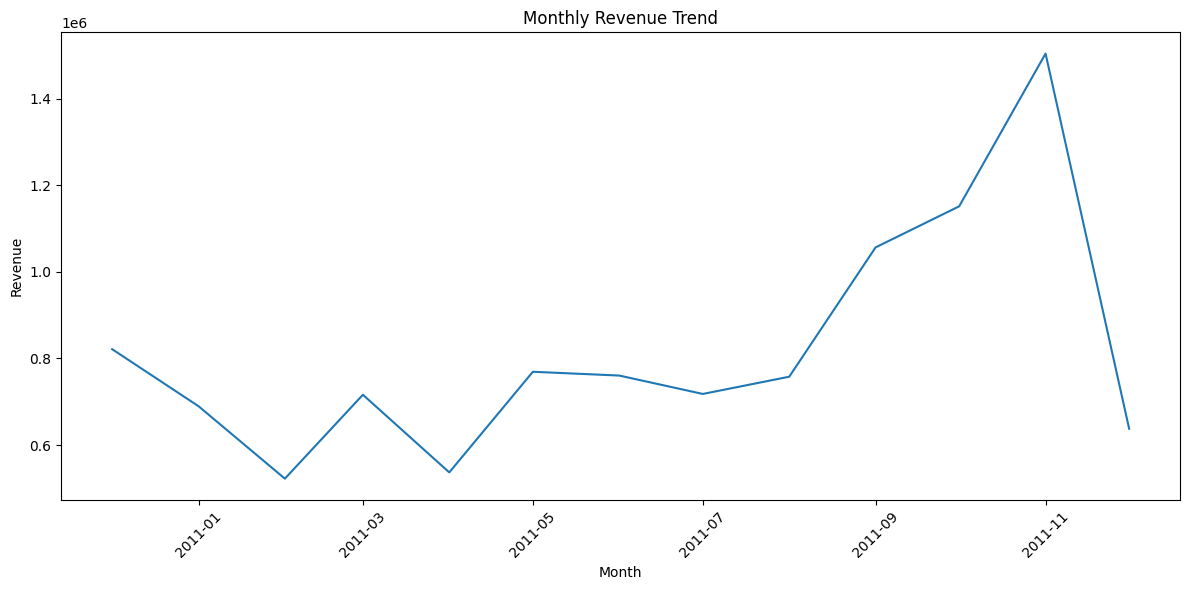

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["Revenue"]
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
monthly_revenue.sort_values(
    "Revenue",
    ascending=False
).head(5)

,Month,Revenue
11,2011-11-01,1503866.780
10,2011-10-01,1151263.730
9,2011-09-01,1056435.192
0,2010-12-01,821452.730
5,2011-05-01,769296.610


In [37]:
monthly_revenue.sort_values(
    "Revenue",
    ascending=True
).head(5)

,Month,Revenue
2,2011-02-01,522545.560
4,2011-04-01,536968.491
12,2011-12-01,637790.330
1,2011-01-01,689811.610
3,2011-03-01,716215.260


In [38]:
top_products_quantity = (
    sales_df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_quantity

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

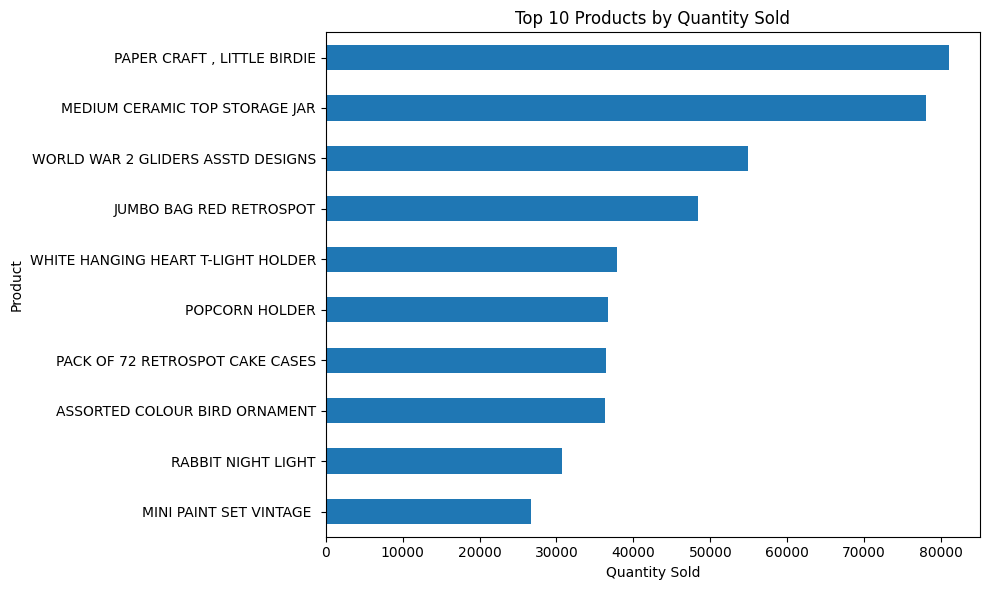

In [39]:
plt.figure(figsize=(10, 6))

top_products_quantity.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [40]:
top_products_revenue = (
    sales_df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_revenue

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: Revenue, dtype: float64

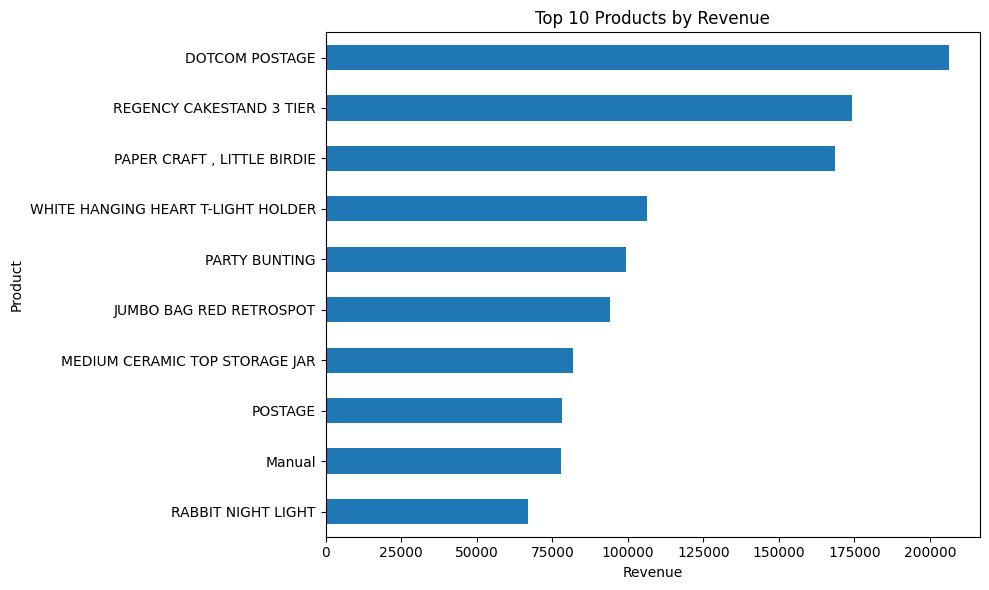

In [41]:
plt.figure(figsize=(10, 6))

top_products_revenue.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [42]:
product_performance = (
    sales_df.groupby("Description")
    .agg(
        Quantity_Sold=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
    .sort_values("Revenue", ascending=False)
)

product_performance.head(10)

,Quantity_Sold,Revenue
Description,,
DOTCOM POSTAGE,706,206248.77
REGENCY CAKESTAND 3 TIER,13851,174156.54
"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60
WHITE HANGING HEART T-LIGHT HOLDER,37872,106236.72
PARTY BUNTING,18283,99445.23
JUMBO BAG RED RETROSPOT,48371,94159.81
MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92
POSTAGE,3150,78101.88
Manual,6985,77752.82


In [43]:
country_revenue = (
    sales_df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

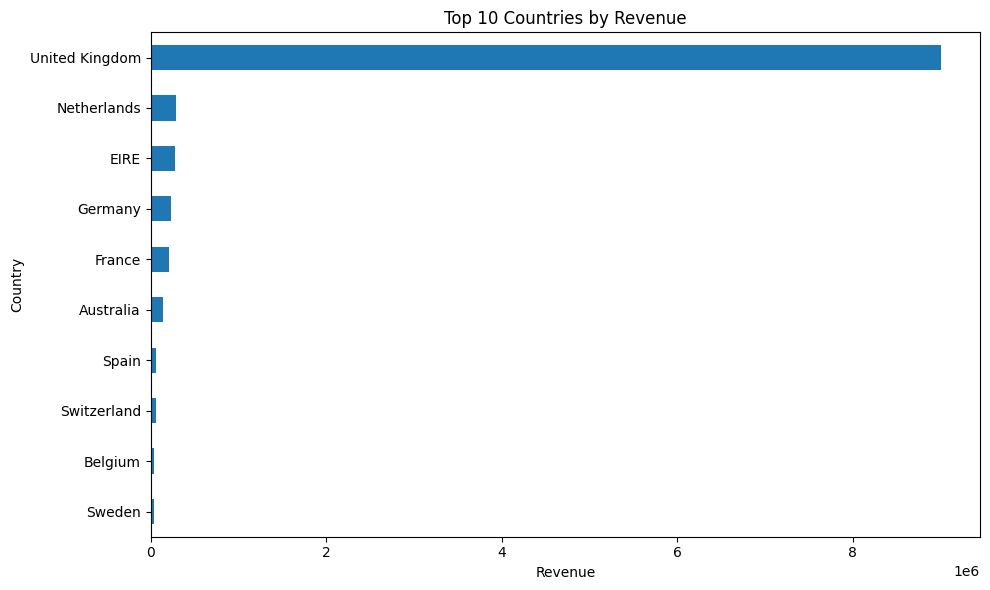

In [44]:
plt.figure(figsize=(10, 6))

country_revenue.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [45]:
country_quantity = (
    sales_df.groupby("Country")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

country_quantity.head(10)

Country
United Kingdom    4646906
Netherlands        200361
EIRE               147007
Germany            119154
France             112060
Australia           83891
Sweden              36078
Switzerland         30617
Spain               27933
Japan               26016
Name: Quantity, dtype: int64

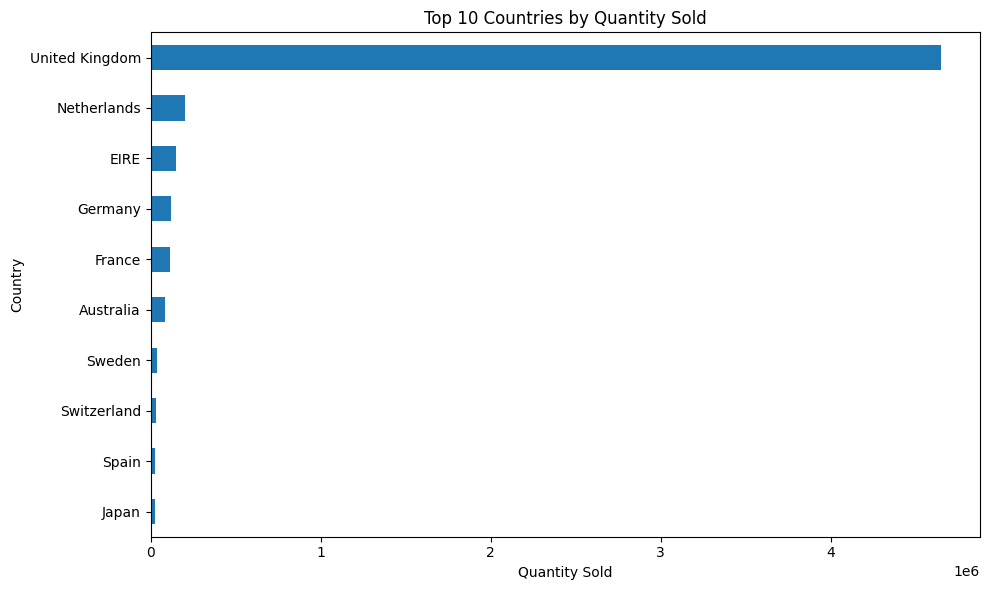

In [46]:
plt.figure(figsize=(10, 6))

country_quantity.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [47]:
country_performance = (
    sales_df.groupby("Country")
    .agg(
        Revenue=("Revenue", "sum"),
        Quantity_Sold=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
    .sort_values("Revenue", ascending=False)
)

country_performance.head(10)

,Revenue,Quantity_Sold,Orders
Country,,,
United Kingdom,9001744.094,4646906,18019
Netherlands,285446.340,200361,94
EIRE,283140.520,147007,288
Germany,228678.400,119154,457
France,209625.370,112060,392
Australia,138453.810,83891,57
Spain,61558.560,27933,90
Switzerland,57067.600,30617,54
Belgium,41196.340,23237,98


In [48]:
top_country = country_performance.index[0]

top_country_revenue = country_performance.iloc[0]["Revenue"]

revenue_share = (top_country_revenue / total_revenue) * 100

print("Top country:", top_country)
print(f"Revenue share: {revenue_share:.2f}%")

Top country: United Kingdom
Revenue share: 84.59%


In [49]:
product_performance.head(20)

,Quantity_Sold,Revenue
Description,,
DOTCOM POSTAGE,706,206248.77
REGENCY CAKESTAND 3 TIER,13851,174156.54
"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60
WHITE HANGING HEART T-LIGHT HOLDER,37872,106236.72
PARTY BUNTING,18283,99445.23
JUMBO BAG RED RETROSPOT,48371,94159.81
MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92
POSTAGE,3150,78101.88
Manual,6985,77752.82


In [50]:
product_value = (
    sales_df.groupby("Description")
    .agg(
        Quantity_Sold=("Quantity", "sum"),
        Revenue=("Revenue", "sum"),
        Average_Unit_Price=("UnitPrice", "mean"),
        Orders=("InvoiceNo", "nunique")
    )
    .sort_values("Revenue", ascending=False)
)

product_value.head(10)

,Quantity_Sold,Revenue,Average_Unit_Price,Orders
Description,,,,
DOTCOM POSTAGE,706,206248.77,292.137068,706
REGENCY CAKESTAND 3 TIER,13851,174156.54,13.983936,1988
"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,2.080000,1
WHITE HANGING HEART T-LIGHT HOLDER,37872,106236.72,3.218334,2256
PARTY BUNTING,18283,99445.23,5.797928,1685
JUMBO BAG RED RETROSPOT,48371,94159.81,2.486197,2089
MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,1.468480,247
POSTAGE,3150,78101.88,31.076581,1126
Manual,6985,77752.82,233.757981,290


In [51]:
top_20_products = product_value.head(20).copy()

top_20_products

,Quantity_Sold,Revenue,Average_Unit_Price,Orders
Description,,,,
DOTCOM POSTAGE,706,206248.77,292.137068,706
REGENCY CAKESTAND 3 TIER,13851,174156.54,13.983936,1988
"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,2.080000,1
WHITE HANGING HEART T-LIGHT HOLDER,37872,106236.72,3.218334,2256
PARTY BUNTING,18283,99445.23,5.797928,1685
JUMBO BAG RED RETROSPOT,48371,94159.81,2.486197,2089
MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,1.468480,247
POSTAGE,3150,78101.88,31.076581,1126
Manual,6985,77752.82,233.757981,290


<Figure size 1000x800 with 0 Axes>

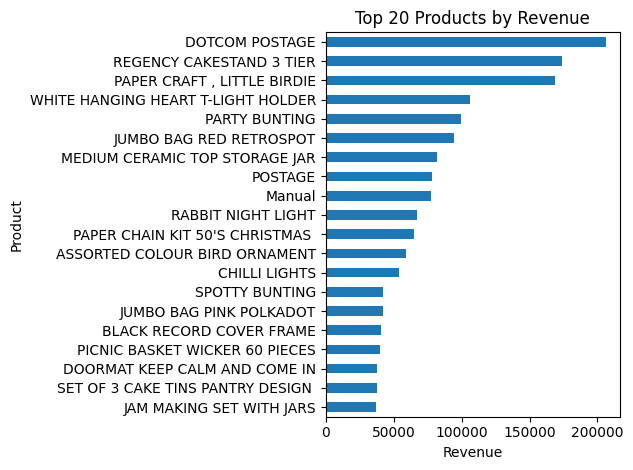

In [52]:
plt.figure(figsize=(10, 8))

top_20_products.sort_values("Revenue").plot(
    y="Revenue",
    kind="barh",
    legend=False
)

plt.title("Top 20 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [53]:
top_quantity_products = product_value.sort_values(
    "Quantity_Sold",
    ascending=False
).head(20)

top_quantity_products

,Quantity_Sold,Revenue,Average_Unit_Price,Orders
Description,,,,
"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,2.080000,1
MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,1.468480,247
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951,13814.01,0.320728,535
JUMBO BAG RED RETROSPOT,48371,94159.81,2.486197,2089
WHITE HANGING HEART T-LIGHT HOLDER,37872,106236.72,3.218334,2256
POPCORN HOLDER,36749,34288.67,1.020836,803
PACK OF 72 RETROSPOT CAKE CASES,36396,21246.45,0.761206,1320
ASSORTED COLOUR BIRD ORNAMENT,36362,58927.62,1.722575,1455
RABBIT NIGHT LIGHT,30739,66870.03,2.386401,994


In [54]:
monthly_revenue.to_csv(
    "monthly_revenue.csv",
    index=False
)

product_value.to_csv(
    "product_performance.csv"
)

country_performance.to_csv(
    "country_performance.csv"
)

In [55]:
sales_df.to_csv("clean_sales_data.csv", index=False)

print("Clean dataset exported successfully!")
print("Rows:", len(sales_df))

Clean dataset exported successfully!
Rows: 524878


# Business Insights & Recommendations
## 1. Key Performance Indicators

The analysis provides an overall view of business sales performance using total revenue, total orders, total quantity sold, and average order value.

- **Total Revenue:** Measures the overall sales revenue generated after cleaning the transaction data.
- **Total Orders:** Represents the number of unique invoices in the cleaned dataset.
- **Total Quantity:** Represents the total number of products sold.
- **Average Order Value:** Represents the average revenue generated per order.

These KPIs provide a high-level view of the company's sales performance and form the foundation for deeper product and regional analysis.

## 2. Monthly Revenue Trend

The monthly revenue analysis shows how sales performance changes over time. The trend helps identify periods of stronger and weaker revenue performance and can support better sales planning, inventory management, and promotional decisions.

The monthly revenue trend is visualized in the Power BI dashboard to make changes in sales performance easy to identify.

## 3. Top Products by Revenue

Product-level analysis identifies the products that contribute the most to overall revenue. The Power BI dashboard highlights the top 10 products by revenue, helping the business identify high-value products and prioritize them for inventory planning, promotion, and sales strategy.

Products generating consistently high revenue should be monitored closely to maintain availability and avoid stock-outs.

## 4. Regional Performance

Country-level analysis compares revenue, quantity sold, and number of orders across different markets. The Power BI dashboard highlights the top 10 countries by revenue.

The results help identify the strongest markets and provide a basis for prioritizing regional sales efforts, marketing activities, and inventory allocation.

## 5. Business Recommendations

Based on the sales performance analysis, the following actions are recommended:

1. **Focus on high-revenue products:** Prioritize top-performing products in inventory planning and promotional campaigns.
2. **Strengthen high-performing markets:** Allocate appropriate marketing and sales resources to countries generating strong revenue.
3. **Monitor monthly trends:** Use monthly revenue patterns to improve sales forecasting, inventory planning, and promotional timing.
4. **Reduce stock-out risk:** Maintain sufficient inventory for products with consistently high demand.
5. **Review underperforming areas:** Investigate products and markets with relatively low revenue to identify opportunities for improvement.

## 6. Data Cleaning & Preparation

The raw online retail dataset was cleaned before analysis.

The following steps were performed:

- Removed duplicate transaction records.
- Removed transactions with non-positive quantities.
- Removed transactions with non-positive unit prices.
- Excluded cancelled invoices identified by invoice numbers beginning with "C".
- Created a Revenue column using Quantity × UnitPrice.
- Converted InvoiceDate into a proper date format for time-based analysis.
- Missing CustomerID values were retained because customer-level analysis was not required for this task.

## 7. Dataset Limitation

The dataset does not contain a separate product-category field. Therefore, the analysis focuses on individual product performance rather than category-level performance.

The analysis should be interpreted as a sales performance overview based on the available transaction, product, and country information.

## 8. Conclusion

This analysis provides a clear overview of business sales performance using transaction-level retail data. The dashboard combines key performance indicators, monthly revenue trends, top products, and country-level performance to support data-driven business decisions.

The analysis can help management identify revenue opportunities, prioritize high-performing products and markets, and improve inventory and sales planning.